# Key perturbations for the phenotype readouts (no-input condition)

Follow-up of `05_analysis_perturbation_noinput.ipynb`. That notebook simulated every single-node lock
(109 nodes × {ON, OFF} + wildtype) with MaBoSS and saved the node-probability trajectories to
`results/maboss_perturbation_noinput_results.csv`. **No simulation is re-run here** — the CSV is reloaded.

Goal: find the perturbations that increase or decrease the three main readouts

| Readout | Wildtype behaviour | Metric used for the effect |
|---|---|---|
| `Apoptosis` | rises from t≈8, plateau ≈0.56 from t≈20 | Δ plateau (mean over t = 30–40) vs wildtype |
| `Proliferation` | plateau ≈0.20 from t≈2 | Δ plateau (mean over t = 30–40) vs wildtype |
| `Autop_digestion` | **transient**: peak ≈0.02 at t≈16, decays to ≈0.01 | log2 fold-change of the AUC (whole time course) + peak, persistence and dynamic class |

A plateau metric would miss most of the autophagy response (it has largely decayed by the end), so
`Autop_digestion` is scored on the whole time course (AUC), on its peak amplitude, and on how much of
the peak is still present at the end (*persistence* = late level / peak). The latter distinguishes
a transient response that is merely amplified from one that has been turned into a sustained one.

**Simulation set-up (from notebook 05)** — keep in mind when comparing with other analyses:
- all inputs OFF, every other node initialised **OFF** (not the random initialisation of the shared
  scenario convention, and `KEAP1`/`NQO1` are not pinned ON — their `_ON` locks are perturbations here);
- 2000 trajectories, `max_time=50`, saved for t = 0–40;
- the `static_node` list in 05 misses a comma (`"Autop_digestion" "Apoptosis"`), so `Apoptosis` and
  `Autop_digestion` *were* perturbed. Locking a readout onto itself is trivial; these *self* perturbations
  are kept in the tables but excluded from the rankings. `Proliferation`, the inputs, `Lysosome_prod`,
  `Atphgo_form` and `Atphgo_mat` were not perturbed.
- Readouts are marginal probabilities over the 2000 trajectories, so they are not mutually exclusive
  (a perturbation can raise both `Apoptosis` and `Proliferation`).

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

RESULTS_FILE = '../../../../results/maboss_perturbation_noinput_results.csv'
MODEL_FILE = '../../../../model/autophagy_september26/Autophagy_and_apoptosis_Sept26.bnet'
results_dir = '../../../../results/'
fig_dir = '../../../../figures/perturbation_output_effects/'
os.makedirs(fig_dir, exist_ok=True)

OUTPUTS = ['Apoptosis', 'Proliferation', 'Autop_digestion']
phenotypes_colors = {'Apoptosis': 'green', 'Proliferation': 'red', 'Autop_digestion': 'black'}
type_colors = {'ON': '#E08214', 'OFF': '#5E3C99'}
type_markers = {'ON': '^', 'OFF': 'v'}

# Analysis parameters
LATE_WINDOW = (30, 40)   # plateau window for Apoptosis / Proliferation (and the late autophagy level)
SMOOTH = 3               # rolling-mean width (time ticks) applied before taking the autophagy peak
EPS = 1e-3               # pseudo-count (per time tick) for the Autop_digestion log2 fold-changes
DELTA_THR = 0.05         # |Δ plateau| called as an effect on Apoptosis / Proliferation
LFC_THR = 1.0            # |log2 FC| (2-fold) called as an effect on Autop_digestion
ABOLISHED_THR = 0.005    # Autop_digestion peak below this (10 / 2000 trajectories) = abolished
SUSTAINED_THR = 0.8      # Autop_digestion late / peak at or above this = no longer transient
TERMINATED_THR = 0.15    # Autop_digestion late / peak below this = transient that switches fully off

## Load the saved simulations

In [3]:
df = pd.read_csv(RESULTS_FILE)
node_cols = df.columns.drop(['mutation', 'timepoint', 'mutation_type'])

# One (timepoint x perturbation) table per readout
traj = {node: df.pivot(index='timepoint', columns='mutation', values=node) for node in OUTPUTS}
t = traj['Apoptosis'].index.values

# Perturbation annotation (node + ON/OFF), parsed from the name ('wildtype' has no lock)
annot = pd.DataFrame(index=traj['Apoptosis'].columns.drop('wildtype'))
annot['node'] = annot.index.str.rsplit('_', n=1).str[0]
annot['mutation_type'] = annot.index.str.rsplit('_', n=1).str[1]
annot['self'] = annot['node'].isin(OUTPUTS)

# Perturbations whose whole trajectory (all nodes) is identical to the wildtype: MaBoSS reuses the
# same seed, so an identical result means the lock never changes the dynamics (e.g. locking OFF a
# node that never turns on without inputs).
wt_values = df.loc[df['mutation'] == 'wildtype', node_cols].values
annot['silent'] = df[df['mutation'] != 'wildtype'].groupby('mutation', sort=False).apply(
    lambda g: np.allclose(g[node_cols].values, wt_values), include_groups=False).reindex(annot.index)

print(f"{df['mutation'].nunique()} simulations ({len(annot)} perturbations + wildtype), "
      f"{len(t)} timepoints ({t.min():g}-{t.max():g}), {len(node_cols)} nodes")
print(f"{annot['silent'].sum()} perturbations are identical to the wildtype "
      f"({(annot['silent'] & (annot['mutation_type'] == 'OFF')).sum()} OFF, "
      f"{(annot['silent'] & (annot['mutation_type'] == 'ON')).sum()} ON)")

219 simulations (218 perturbations + wildtype), 41 timepoints (0-40), 119 nodes
39 perturbations are identical to the wildtype (39 OFF, 0 ON)


Rules of the three readouts (and of the autophagy pipeline above `Autop_digestion`):

In [3]:
rules = {}
with open(MODEL_FILE) as f:
    for line in f:
        if ',' in line and not line.startswith(('#', 'targets')):
            target, rule = line.split(',', 1)
            rules[target.strip()] = rule.strip()

for node in ['Apoptosis', 'Proliferation', 'Autop_digestion', 'Atphgo_mat', 'Atphgo_form']:
    print(f'{node:16s} = {rules[node]}')

Apoptosis        = Caspase_3_6_7_C
Proliferation    = EIF4E&Cell_cycle
Autop_digestion  = Atphgo_mat
Atphgo_mat       = RAB7A&Atphgo_form
Atphgo_form      = MAP1LC3A_II&WIPI_1


## Wildtype dynamics and choice of the metrics
The shaded band is the plateau window used for `Apoptosis` and `Proliferation`. `Autop_digestion` is
shown on its own axis (its scale is ~25× smaller) together with its smoothed curve, peak and late level.

In [17]:
traj.keys()

dict_keys(['Apoptosis', 'Proliferation', 'Autop_digestion'])

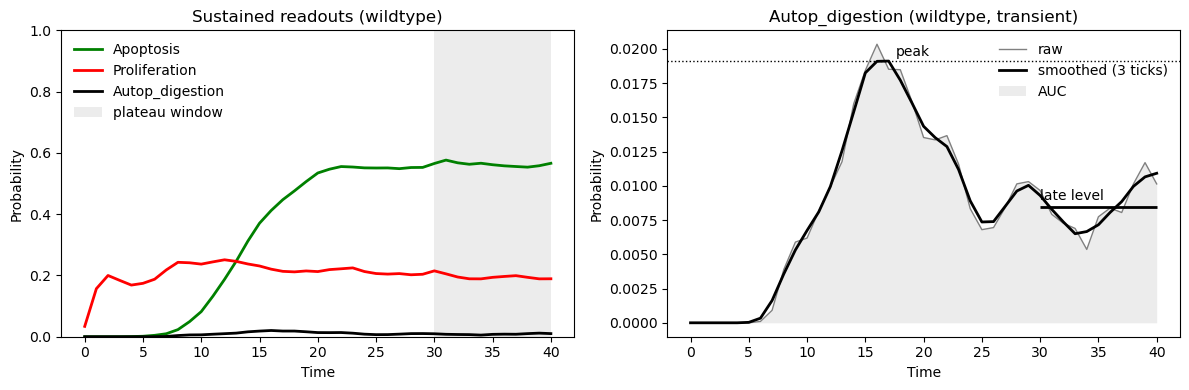

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for node in ['Apoptosis', 'Proliferation','Autop_digestion']:
    ax.plot(t, traj[node]['wildtype'], color=phenotypes_colors[node], lw=2, label=node)
ax.axvspan(*LATE_WINDOW, color='grey', alpha=0.15, lw=0, label='plateau window')
ax.set(xlabel='Time', ylabel='Probability', ylim=(0, 1), title='Sustained readouts (wildtype)')
ax.legend(frameon=False)

ax = axes[1]
ad_wt = traj['Autop_digestion']['wildtype']
ad_wt_smooth = ad_wt.rolling(SMOOTH, center=True, min_periods=1).mean()
ax.plot(t, ad_wt, color='grey', lw=1, label='raw')
ax.plot(t, ad_wt_smooth, color=phenotypes_colors['Autop_digestion'], lw=2, label=f'smoothed ({SMOOTH} ticks)')
ax.fill_between(t, 0, ad_wt, color='grey', alpha=0.15, lw=0, label='AUC')
ax.axhline(ad_wt_smooth.max(), color='black', ls=':', lw=1)
ax.annotate('peak', (ad_wt_smooth.idxmax(), ad_wt_smooth.max()), textcoords='offset points', xytext=(5, 4))
ax.hlines(ad_wt.loc[LATE_WINDOW[0]:LATE_WINDOW[1]].mean(), *LATE_WINDOW, color='black', lw=2)
ax.annotate('late level', (LATE_WINDOW[0], ad_wt.loc[LATE_WINDOW[0]:].mean()), textcoords='offset points', xytext=(0, 5))
ax.set(xlabel='Time', ylabel='Probability', title='Autop_digestion (wildtype, transient)')
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
fig.savefig(fig_dir + 'wildtype_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## Per-perturbation metrics
- `*_late`: mean over the plateau window;
- `Apoptosis_t_half`: first time `Apoptosis` reaches half of its *own* plateau (onset speed, independent of the level);
- `Autop_digestion_peak` / `_t_peak`: on the smoothed curve; `_auc`: trapezoidal area on the raw curve;
- `Autop_digestion_persistence` = late level / peak (≈0.45 in the wildtype; →1 when the response no longer decays).

In [5]:
def late_mean(w):
    return w.loc[LATE_WINDOW[0]:LATE_WINDOW[1]].mean()

def auc(w):
    return pd.Series(np.trapezoid(w.values, w.index.values, axis=0), index=w.columns)

def t_half(w, level):
    # first time each column reaches `level` (NaN if never)
    reached = w.ge(level, axis=1)
    return reached.idxmax().where(reached.any())

apo, pro, ad = traj['Apoptosis'], traj['Proliferation'], traj['Autop_digestion']
ad_smooth = ad.rolling(SMOOTH, center=True, min_periods=1).mean()

metrics = pd.DataFrame({
    'Apoptosis_late': late_mean(apo),
    'Apoptosis_auc': auc(apo),
    'Apoptosis_t_half': t_half(apo, late_mean(apo) / 2).where(late_mean(apo) >= DELTA_THR),
    'Proliferation_late': late_mean(pro),
    'Proliferation_auc': auc(pro),
    'Autop_digestion_peak': ad_smooth.max(),
    'Autop_digestion_t_peak': ad_smooth.idxmax(),
    'Autop_digestion_auc': auc(ad),
    'Autop_digestion_late': late_mean(ad),
})
metrics['Autop_digestion_persistence'] = (metrics['Autop_digestion_late'] / metrics['Autop_digestion_peak']).clip(upper=1)
metrics.loc[metrics['Autop_digestion_peak'] < ABOLISHED_THR, ['Autop_digestion_t_peak', 'Autop_digestion_persistence']] = np.nan

wt = metrics.loc['wildtype']
wt.round(3).to_frame('wildtype').T

,Apoptosis_late,Apoptosis_auc,Apoptosis_t_half,Proliferation_late,Proliferation_auc,Autop_digestion_peak,Autop_digestion_t_peak,Autop_digestion_auc,Autop_digestion_late,Autop_digestion_persistence
wildtype,0.563,14.665,14.0,0.196,8.271,0.019,17.0,0.346,0.008,0.443


### Effect sizes
- `Apoptosis`, `Proliferation`: Δ plateau = perturbation − wildtype (probability units).
- `Autop_digestion`: log2 fold-change of the AUC (primary) and of the peak, with a pseudo-count of
  `EPS` per time tick so that abolished responses get a finite value.

In [6]:
duration = t.max() - t.min()

effects = pd.DataFrame({
    'Apoptosis': metrics['Apoptosis_late'] - wt['Apoptosis_late'],
    'Proliferation': metrics['Proliferation_late'] - wt['Proliferation_late'],
    'Autop_digestion': np.log2((metrics['Autop_digestion_auc'] + EPS * duration) /
                               (wt['Autop_digestion_auc'] + EPS * duration)),
}).drop(index='wildtype')
effects_extra = pd.DataFrame({
    'Apoptosis_auc_delta': metrics['Apoptosis_auc'] - wt['Apoptosis_auc'],
    'Apoptosis_t_half_delta': metrics['Apoptosis_t_half'] - wt['Apoptosis_t_half'],
    'Autop_digestion_peak_lfc': np.log2((metrics['Autop_digestion_peak'] + EPS) / (wt['Autop_digestion_peak'] + EPS)),
}).drop(index='wildtype')

thresholds = {'Apoptosis': DELTA_THR, 'Proliferation': DELTA_THR, 'Autop_digestion': LFC_THR}
effect_labels = {'Apoptosis': 'Δ Apoptosis plateau', 'Proliferation': 'Δ Proliferation plateau',
                 'Autop_digestion': 'log2 FC Autop_digestion AUC'}

def call(x, thr):
    return pd.Series(np.select([x >= thr, x <= -thr], ['up', 'down'], 'ns'), index=x.index)

calls = pd.DataFrame({node: call(effects[node], thr) for node, thr in thresholds.items()})

### Are the thresholds above the simulation noise?
With 2000 trajectories the standard error of a probability *p* is √(p(1−p)/2000) (≈0.011 at p = 0.56), and
it is further reduced by averaging over the plateau window. The fluctuation of the wildtype inside the
window gives the same order of magnitude. Δ = 0.05 is therefore ≥ 5 SE; for `Autop_digestion` a 2-fold
change in AUC is used because its absolute values are tiny (wildtype peak ≈0.02 ≈ 40 trajectories).

,wildtype plateau,binomial SE (one timepoint),wildtype SD inside the window
Apoptosis,0.5628,0.0111,0.0066
Proliferation,0.1959,0.0089,0.0081
Autop_digestion,0.0085,0.0031,0.0018


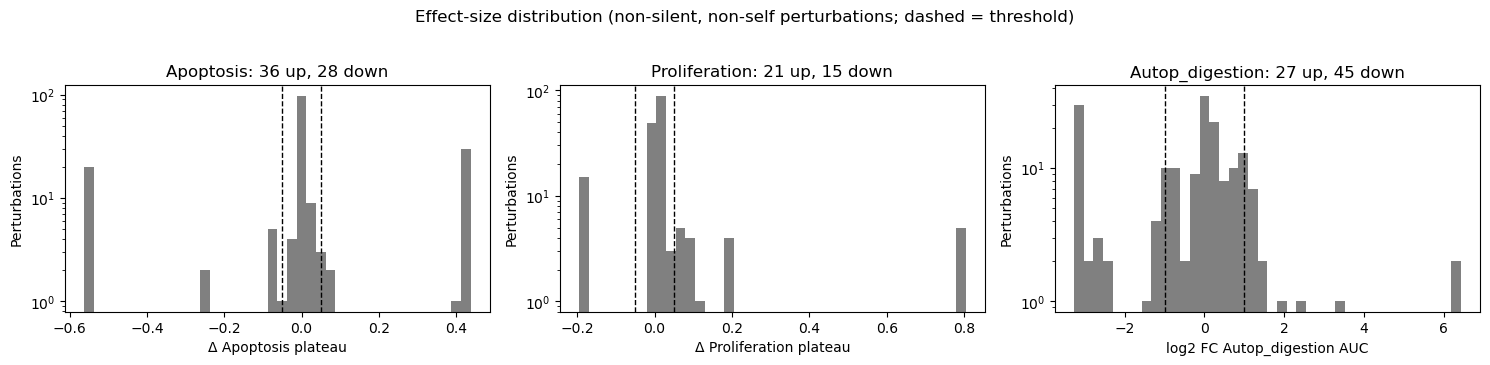

In [7]:
n_samples = 2000
noise = pd.DataFrame({
    'wildtype plateau': [wt['Apoptosis_late'], wt['Proliferation_late'], wt['Autop_digestion_late']],
    'binomial SE (one timepoint)': [np.sqrt(p * (1 - p) / n_samples) for p in
                                    [wt['Apoptosis_late'], wt['Proliferation_late'], wt['Autop_digestion_peak']]],
    'wildtype SD inside the window': [late_window.std() for late_window in
                                      [traj[n]['wildtype'].loc[LATE_WINDOW[0]:LATE_WINDOW[1]] for n in OUTPUTS]],
}, index=OUTPUTS)
display(noise.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, node in zip(axes, OUTPUTS):
    x = effects.loc[~annot['self'], node]
    ax.hist(x[~annot['silent']], bins=40, color='grey')
    for s in (-1, 1):
        ax.axvline(s * thresholds[node], color='black', ls='--', lw=1)
    ax.set(xlabel=effect_labels[node], ylabel='Perturbations', yscale='log',
           title=f'{node}: {(calls.loc[x.index, node] == "up").sum()} up, '
                 f'{(calls.loc[x.index, node] == "down").sum()} down')
fig.suptitle('Effect-size distribution (non-silent, non-self perturbations; dashed = threshold)', y=1.03)
fig.tight_layout()
fig.savefig(fig_dir + 'effect_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Ranked perturbations per readout
Top increases (right) and decreases (left) beyond the threshold, excluding the self-locks. Bars are
coloured by the type of lock (▲ ON / ▼ OFF).

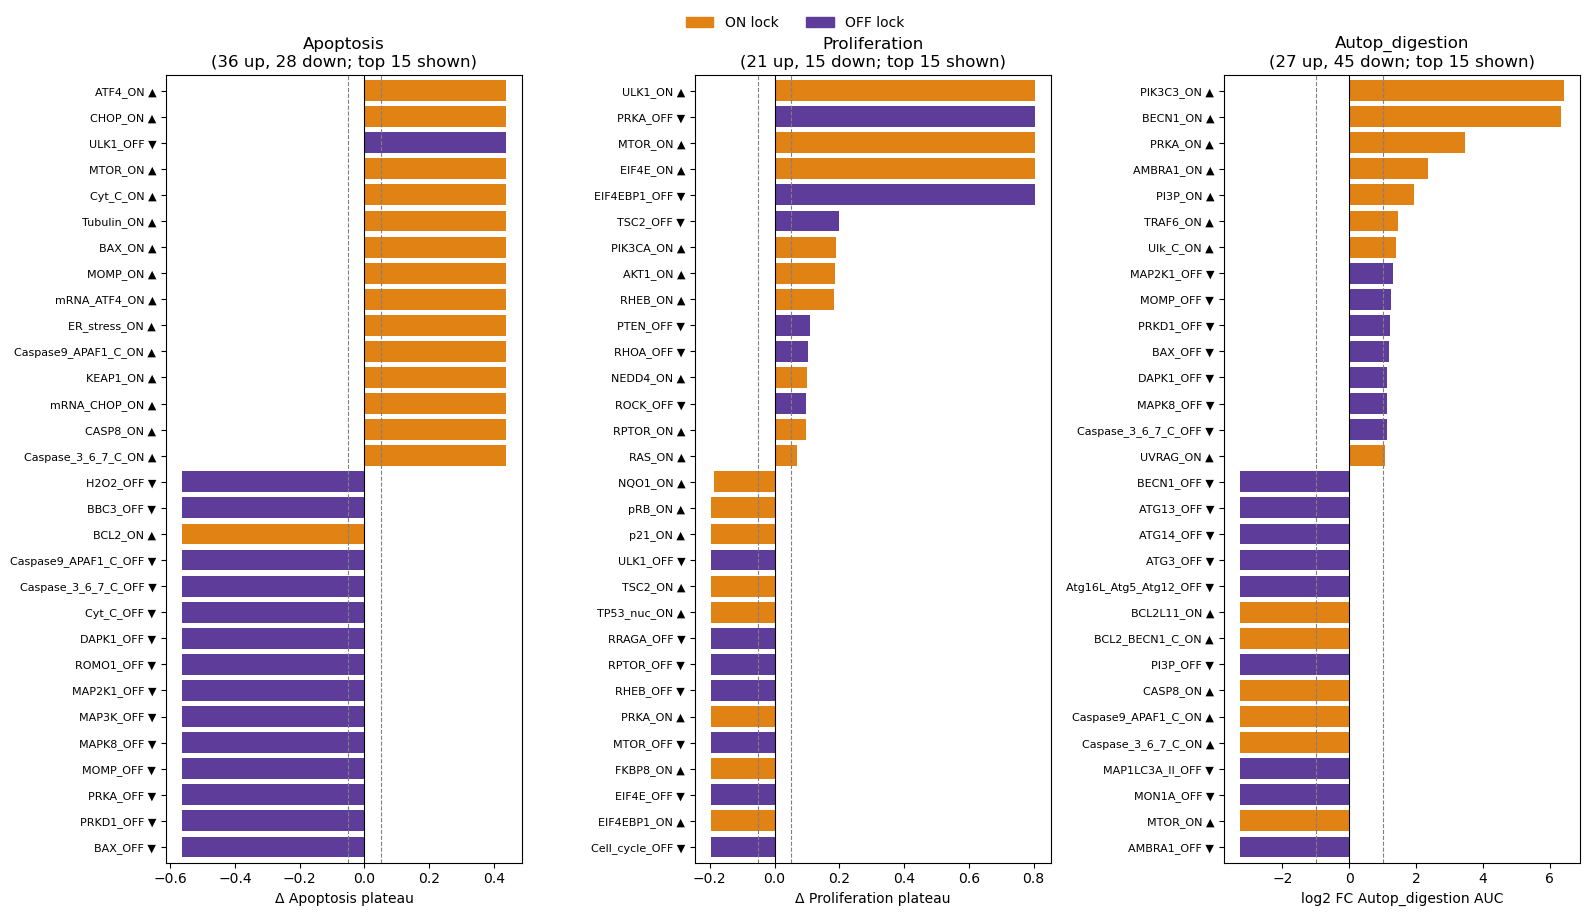

In [8]:
TOP_N = 15

def plot_ranking(node, ax, top_n=TOP_N):
    x = effects.loc[~annot['self'], node]
    sig = x[calls.loc[x.index, node] != 'ns']
    top = pd.concat([sig.nsmallest(top_n), sig.nlargest(top_n)])
    top = top[~top.index.duplicated()].sort_values()
    colors = annot.loc[top.index, 'mutation_type'].map(type_colors)
    ax.barh(range(len(top)), top.values, color=colors, height=0.8)
    ax.set_yticks(range(len(top)), [f"{i} {'▲' if annot.loc[i, 'mutation_type'] == 'ON' else '▼'}" for i in top.index],
                  fontsize=8)
    ax.axvline(0, color='black', lw=0.8)
    for s in (-1, 1):
        ax.axvline(s * thresholds[node], color='grey', ls='--', lw=0.8)
    ax.set(xlabel=effect_labels[node], ylim=(-0.6, len(top) - 0.4),
           title=f'{node}\n({(sig > 0).sum()} up, {(sig < 0).sum()} down; top {top_n} shown)')

fig, axes = plt.subplots(1, 3, figsize=(16, 9))
for ax, node in zip(axes, OUTPUTS):
    plot_ranking(node, ax)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in type_colors.values()]
fig.legend(handles, [f'{k} lock' for k in type_colors], loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
fig.savefig(fig_dir + 'ranking_per_output.png', dpi=300, bbox_inches='tight')
fig.savefig(fig_dir + 'ranking_per_output.pdf', bbox_inches='tight')
plt.show()

Trajectories of the strongest perturbations (top 5 up and top 5 down by effect size) next to the
wildtype (dashed black):

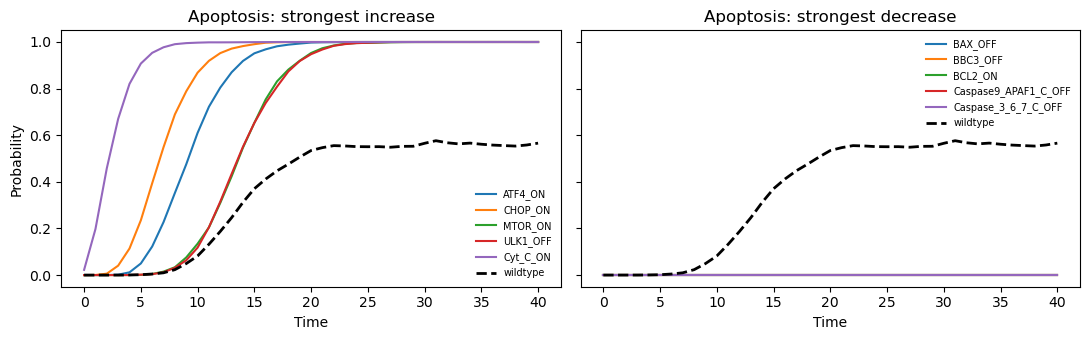

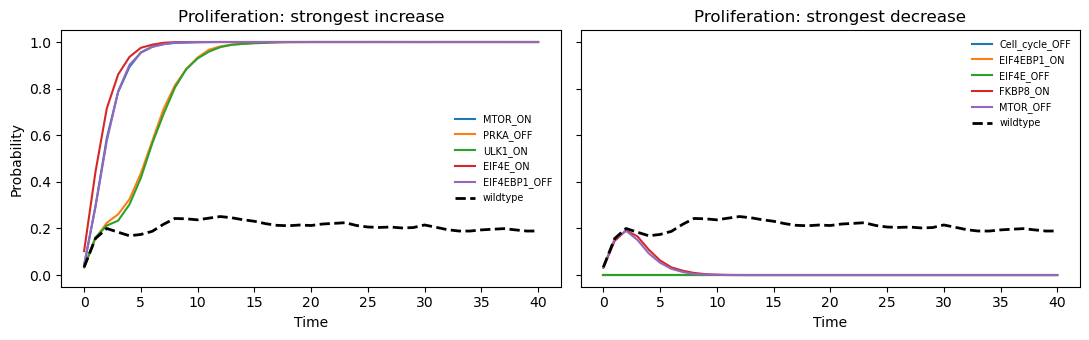

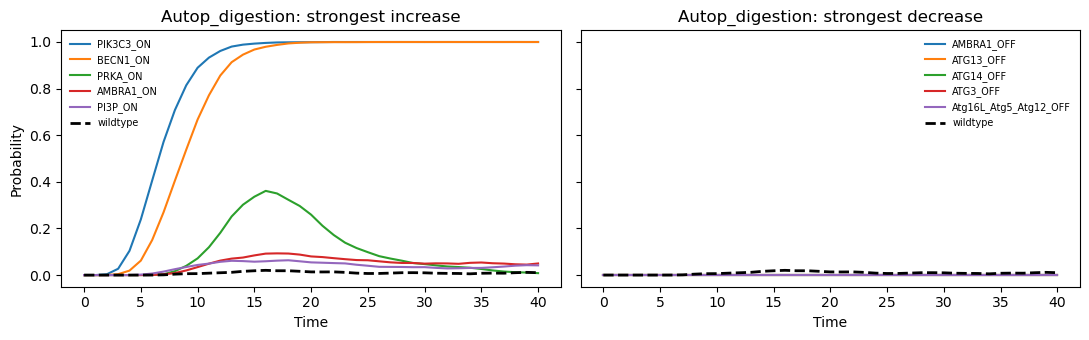

In [9]:
def plot_top_trajectories(node, n=5):
    x = effects.loc[~annot['self'], node]
    sig = x[calls.loc[x.index, node] != 'ns']
    groups = {'increase': sig.nlargest(n).index, 'decrease': sig.nsmallest(n).index}
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
    for ax, (label, idx) in zip(axes, groups.items()):
        for i, pert in enumerate(idx):
            ax.plot(t, traj[node][pert], lw=1.5, color=plt.cm.tab10(i), label=pert)
        ax.plot(t, traj[node]['wildtype'], color='black', ls='--', lw=2, label='wildtype')
        ax.set(xlabel='Time', title=f'{node}: strongest {label}')
        ax.legend(fontsize=7, frameon=False)
    axes[0].set_ylabel('Probability')
    fig.tight_layout()
    fig.savefig(fig_dir + f'top_trajectories_{node}.png', dpi=300, bbox_inches='tight')
    plt.show()

for node in OUTPUTS:
    plot_top_trajectories(node)

## Autop_digestion: what happens to the transient?
An increase in AUC can mean a larger transient or a response that no longer switches off, and a decrease
can mean a weaker transient or no autophagy at all. Each perturbation is therefore assigned a dynamic class:

| Class | Rule |
|---|---|
| `abolished` | smoothed peak < `ABOLISHED_THR` |
| `sustained` | persistence (late / peak) ≥ `SUSTAINED_THR` — the response no longer decays |
| `terminated` | persistence < `TERMINATED_THR` — a transient that switches *fully* off (the wildtype keeps ≈45 % of its peak) |
| `transient` | otherwise (wildtype-like shape) |

Independently of the class, the peak amplitude is compared with the wildtype (`autophagy_amplitude`, ≥ 2-fold).

In [10]:
def autophagy_class(row):
    if row['Autop_digestion_peak'] < ABOLISHED_THR:
        return 'abolished'
    if row['Autop_digestion_persistence'] >= SUSTAINED_THR:
        return 'sustained'
    if row['Autop_digestion_persistence'] < TERMINATED_THR:
        return 'terminated'
    return 'transient'

annot['autophagy_class'] = metrics.drop(index='wildtype').apply(autophagy_class, axis=1)
annot['autophagy_amplitude'] = call(effects_extra['Autop_digestion_peak_lfc'], LFC_THR)
print('wildtype class:', autophagy_class(wt))
pd.crosstab(annot.loc[~annot['self'], 'autophagy_class'], annot.loc[~annot['self'], 'autophagy_amplitude'],
            margins=True).rename(columns=lambda c: f'peak {c}')

wildtype class: transient


autophagy_amplitude,peak down,peak ns,peak up,peak All
autophagy_class,,,,
abolished,37,0,0,37
sustained,0,15,5,20
terminated,0,17,1,18
transient,3,132,4,139
All,40,164,10,214


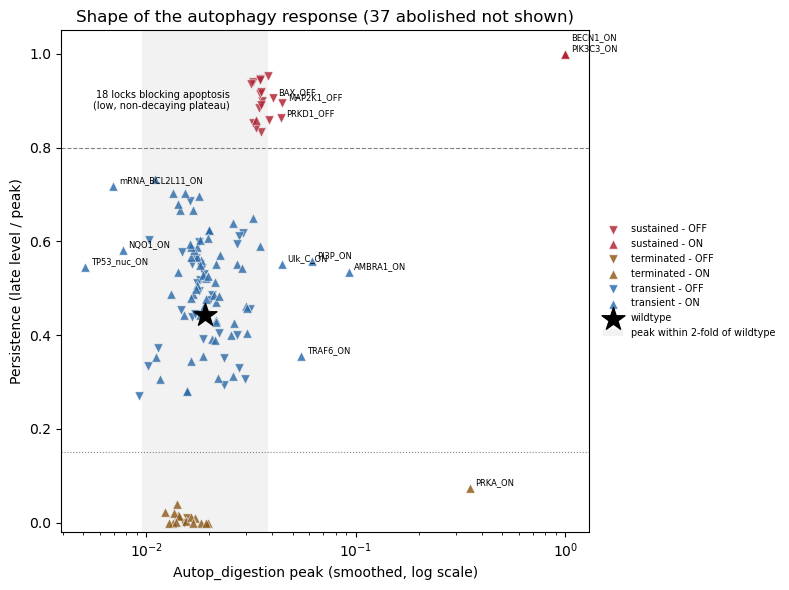

In [11]:
class_colors = {'abolished': '#9E9E9E', 'terminated': '#8C510A', 'transient': '#2166AC', 'sustained': '#B2182B'}
sel = metrics.drop(index='wildtype').loc[~annot['self']].join(annot[['autophagy_class', 'mutation_type']])
sel = sel[sel['autophagy_class'] != 'abolished']

fig, ax = plt.subplots(figsize=(8, 6))
for (cls, mtype), grp in sel.groupby(['autophagy_class', 'mutation_type']):
    ax.scatter(grp['Autop_digestion_peak'], grp['Autop_digestion_persistence'], s=45, alpha=0.8,
               color=class_colors[cls], marker=type_markers[mtype], label=f'{cls} - {mtype}', edgecolor='white', lw=0.5)
ax.scatter(wt['Autop_digestion_peak'], wt['Autop_digestion_persistence'], marker='*', s=300, color='black',
           label='wildtype', zorder=5)

# Label the perturbations that change the peak >= 2-fold (perturbations at the same point share one label);
# the sustained cluster is listed below the figure instead
to_label = sel[(effects_extra.loc[sel.index, 'Autop_digestion_peak_lfc'].abs() >= LFC_THR)]
for _, grp in to_label.groupby([to_label['Autop_digestion_peak'].round(2), to_label['Autop_digestion_persistence'].round(2)]):
    ax.annotate('\n'.join(grp.index), (grp['Autop_digestion_peak'].iloc[0], grp['Autop_digestion_persistence'].iloc[0]),
                fontsize=6, textcoords='offset points', xytext=(4, 2))
n_low_sust = ((sel['autophagy_class'] == 'sustained') & (sel['Autop_digestion_peak'] < 0.1)).sum()
ax.annotate(f'{n_low_sust} locks blocking apoptosis\n(low, non-decaying plateau)', (0.03, 0.9), fontsize=7,
            textcoords='offset points', xytext=(-12, 0), va='center', ha='right')

ax.axhline(SUSTAINED_THR, color='grey', ls='--', lw=0.8)
ax.axhline(TERMINATED_THR, color='grey', ls=':', lw=0.8)
ax.axvspan(wt['Autop_digestion_peak'] / 2, wt['Autop_digestion_peak'] * 2, color='grey', alpha=0.1, lw=0,
           label='peak within 2-fold of wildtype')
ax.set(xscale='log', xlabel='Autop_digestion peak (smoothed, log scale)',
       ylabel='Persistence (late level / peak)', ylim=(-0.02, 1.05),
       title=f'Shape of the autophagy response ({((annot["autophagy_class"] == "abolished") & ~annot["self"]).sum()} abolished not shown)')
ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.tight_layout()
fig.savefig(fig_dir + 'autophagy_peak_vs_persistence.png', dpi=300, bbox_inches='tight')
plt.show()

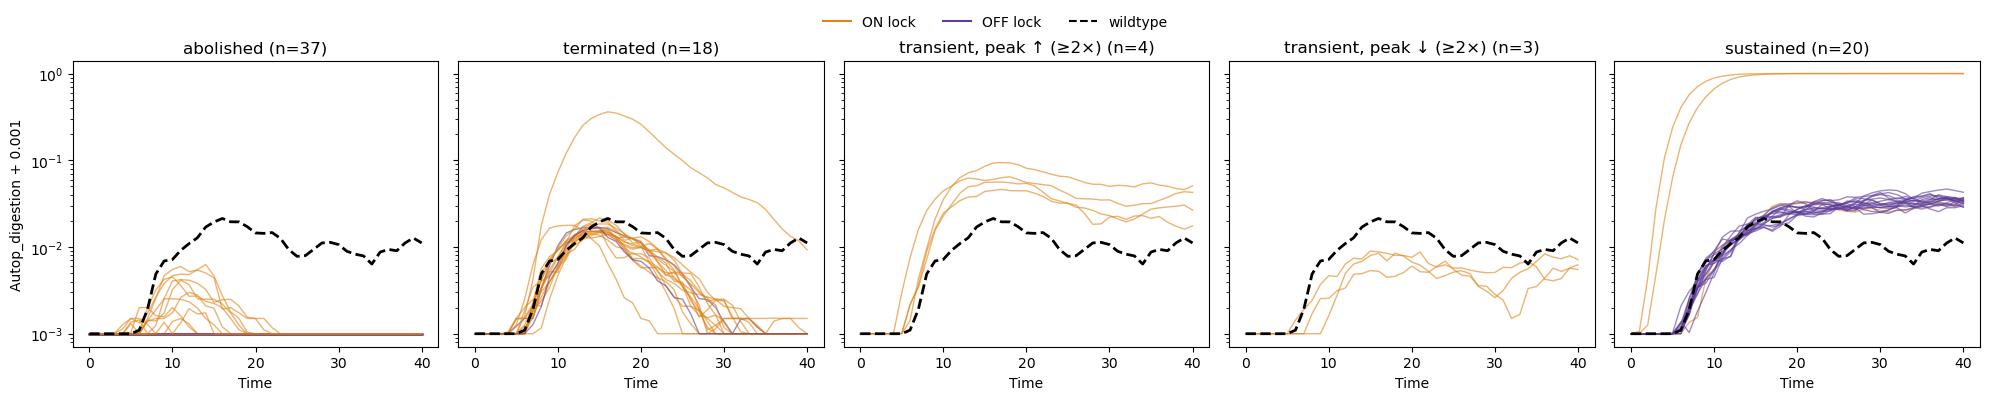

abolished: AKT1_ON, AMBRA1_OFF, ATF4_ON, ATG13_OFF, ATG14_OFF, ATG3_OFF, Atg16L_Atg5_Atg12_OFF, BAX_ON, BCL2L11_ON, BCL2_BECN1_C_ON, BECN1_OFF, CASP8_ON, CHOP_ON, Caspase9_APAF1_C_ON, Caspase_3_6_7_C_ON, Cyt_C_ON, EIF2AK3_ON, ER_stress_ON, MAP1LC3A_II_OFF, MOMP_ON, MON1A_OFF, MTOR_ON, PI3P_OFF, PIK3C3_OFF, PIK3CA_ON, PRKA_OFF, RAB7A_OFF, RB1CC1_OFF, TP53_cyto_ON, TRAF6_OFF, ULK1_OFF, UVRAG_OFF, Ulk_C_OFF, WIPI_1_OFF, YWHAB_ON, mRNA_ATF4_ON, mRNA_CHOP_ON

terminated: BCL2_OFF, Ca_cyto_ON, DAPK1_ON, EGFR_ON, GRB2_ON, IRE1_ON, KEAP1_ON, MAP2K1_ON, MAP3K_ON, MAPK8_ON, PRKA_ON, PRKD1_ON, RAF_ON, RAS_ON, SOS_ON, Tubulin_ON, ULK1_ON, mRNA_BCL2_OFF

transient, peak ↑ (≥2×): AMBRA1_ON, PI3P_ON, TRAF6_ON, Ulk_C_ON

transient, peak ↓ (≥2×): NQO1_ON, TP53_nuc_ON, mRNA_BCL2L11_ON

sustained: BAX_OFF, BBC3_OFF, BCL2_ON, BECN1_ON, Caspase9_APAF1_C_OFF, Caspase_3_6_7_C_OFF, Cyt_C_OFF, DAPK1_OFF, H2O2_OFF, MAP2K1_OFF, MAP3K_OFF, MAPK8_OFF, MOMP_OFF, PIK3C3_ON, PRKD1_OFF, ROMO1_OFF, SP1_OFF, mRNA_BBC3_O

In [12]:
# Trajectories per dynamic class (wildtype dashed); log y-axis because amplitudes span 3 orders of magnitude
groups = {
    'abolished': annot.index[(annot['autophagy_class'] == 'abolished') & ~annot['self']],
    'terminated': annot.index[(annot['autophagy_class'] == 'terminated') & ~annot['self']],
    'transient, peak ↑ (≥2×)': annot.index[(annot['autophagy_class'] == 'transient') & (annot['autophagy_amplitude'] == 'up') & ~annot['self']],
    'transient, peak ↓ (≥2×)': annot.index[(annot['autophagy_class'] == 'transient') & (annot['autophagy_amplitude'] == 'down') & ~annot['self']],
    'sustained': annot.index[(annot['autophagy_class'] == 'sustained') & ~annot['self']],
}

fig, axes = plt.subplots(1, len(groups), figsize=(4 * len(groups), 3.8), sharey=True)
for ax, (label, idx) in zip(axes, groups.items()):
    for pert in idx:
        ax.plot(t, ad[pert] + EPS, color=type_colors[annot.loc[pert, 'mutation_type']], lw=1, alpha=0.6)
    ax.plot(t, ad['wildtype'] + EPS, color='black', ls='--', lw=2)
    ax.set(yscale='log', xlabel='Time', title=f'{label} (n={len(idx)})')
axes[0].set_ylabel(f'Autop_digestion + {EPS:g}')
handles = [plt.Line2D([], [], color=c) for c in type_colors.values()] + [plt.Line2D([], [], color='black', ls='--')]
fig.legend(handles, ['ON lock', 'OFF lock', 'wildtype'], loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.tight_layout()
fig.savefig(fig_dir + 'autophagy_class_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

for label, idx in groups.items():
    print(f'{label}: {", ".join(sorted(idx))}\n')

Is the shape of the autophagy response linked to the apoptosis outcome? In the model the executioner
caspase shuts the pipeline down at its entry point (`BECN1` and `AMBRA1` both require `!Caspase_3_6_7_C`), so
trajectories that commit to apoptosis lose their autophagy — which would make the wildtype transient a
consequence of the apoptotic switch.

In [13]:
pd.crosstab(annot.loc[~annot['self'], 'autophagy_class'], calls.loc[~annot['self'], 'Apoptosis'].rename('Apoptosis call'))

Apoptosis call,down,ns,up
autophagy_class,,,
abolished,1,20,16
sustained,20,0,0
terminated,1,0,17
transient,6,130,3


## Apoptosis kinetics
Some perturbations leave the apoptosis plateau unchanged but change *when* it is reached. `Apoptosis_t_half`
is the first time the probability reaches half of its own plateau.

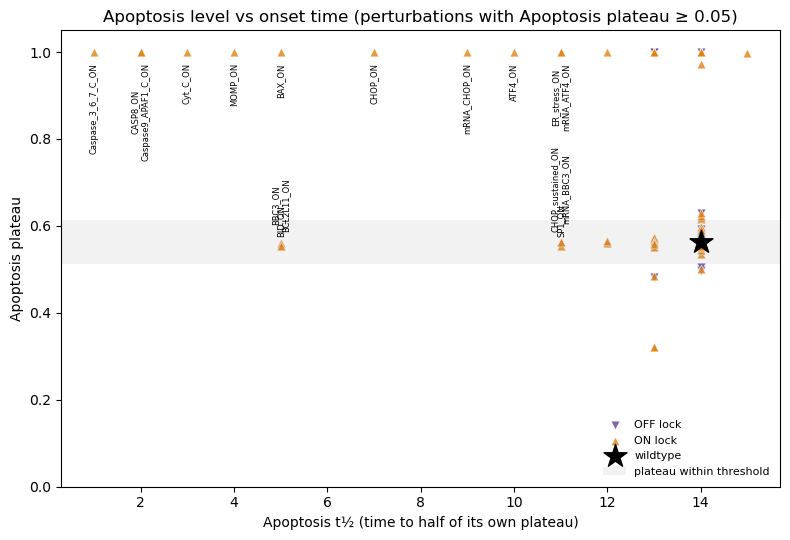

Onset >= 3 ticks earlier than wildtype (t½ = 14):


mutation,Caspase_3_6_7_C_ON,CASP8_ON,Caspase9_APAF1_C_ON,Cyt_C_ON,MOMP_ON,BID_ON,BBC3_ON,BCL2L11_ON,BAX_ON,CHOP_ON,mRNA_CHOP_ON,ATF4_ON,SP1_ON,CHOP_sustained_ON,mRNA_BBC3_ON,ER_stress_ON,mRNA_ATF4_ON
Apoptosis_t_half,1.0,2.0,2.0,3.0,4.0,5.00,5.00,5.00,5.0,7.0,9.0,10.0,11.00,11.00,11.00,11.0,11.0
t_half_shift,-13.0,-12.0,-12.0,-11.0,-10.0,-9.00,-9.00,-9.00,-9.0,-7.0,-5.0,-4.0,-3.00,-3.00,-3.00,-3.0,-3.0
Apoptosis_late,1.0,1.0,1.0,1.0,1.0,0.55,0.56,0.56,1.0,1.0,1.0,1.0,0.55,0.56,0.56,1.0,1.0


Perturbations with no apoptosis (plateau < 0.05): BAX_OFF, BBC3_OFF, BCL2_ON, Caspase9_APAF1_C_OFF, Caspase_3_6_7_C_OFF, Cyt_C_OFF, DAPK1_OFF, H2O2_OFF, MAP2K1_OFF, MAP3K_OFF, MAPK8_OFF, MOMP_OFF, PRKA_OFF, PRKD1_OFF, ROMO1_OFF, SP1_OFF, ULK1_ON, mRNA_BBC3_OFF, mRNA_ROMO1_OFF, mRNA_SP1_OFF


In [14]:
kin = metrics.drop(index='wildtype').loc[~annot['self'], ['Apoptosis_late', 'Apoptosis_t_half']].join(annot['mutation_type'])
kin = kin.dropna()

fig, ax = plt.subplots(figsize=(8, 5.5))
for mtype, grp in kin.groupby('mutation_type'):
    ax.scatter(grp['Apoptosis_t_half'], grp['Apoptosis_late'], color=type_colors[mtype], marker=type_markers[mtype],
               s=40, alpha=0.8, edgecolor='white', lw=0.5, label=f'{mtype} lock')
ax.scatter(wt['Apoptosis_t_half'], wt['Apoptosis_late'], marker='*', s=300, color='black', label='wildtype', zorder=5)
ax.axhspan(wt['Apoptosis_late'] - DELTA_THR, wt['Apoptosis_late'] + DELTA_THR, color='grey', alpha=0.1, lw=0,
           label='plateau within threshold')

# Label the perturbations whose onset moves by >= 3 time ticks (perturbations at the same point share one label)
shift = kin['Apoptosis_t_half'] - wt['Apoptosis_t_half']
to_label = kin[shift.abs() >= 3]
for (x, y), grp in to_label.groupby(['Apoptosis_t_half', to_label['Apoptosis_late'].round(2)]):
    top = y > 0.9
    ax.annotate('\n'.join(grp.index), (x, y), fontsize=6, rotation=90, ha='center',
                va='top' if top else 'bottom', textcoords='offset points', xytext=(0, -8 if top else 8))
ax.set(xlabel='Apoptosis t½ (time to half of its own plateau)', ylabel='Apoptosis plateau', ylim=(0, 1.05),
       title='Apoptosis level vs onset time (perturbations with Apoptosis plateau ≥ 0.05)')
ax.legend(fontsize=8, frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig(fig_dir + 'apoptosis_kinetics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Onset >= 3 ticks earlier than wildtype (t½ = {wt["Apoptosis_t_half"]:g}):')
display(kin[shift <= -3].assign(t_half_shift=shift).sort_values(['Apoptosis_t_half', 'Apoptosis_late'])
        [['Apoptosis_t_half', 't_half_shift', 'Apoptosis_late']].round(2).T)
print('Perturbations with no apoptosis (plateau < 0.05):',
      ', '.join(sorted(annot.index[(metrics.loc[annot.index, 'Apoptosis_late'] < DELTA_THR) & ~annot['self']])))

## Combined view: phenotype shift of each perturbation
Every non-silent, non-self perturbation with at least one effect, with the three effects scaled by their
own threshold (|value| ≥ 1 = called effect; colour clipped at ±5). Rows are grouped by the up / down
pattern across the three readouts.

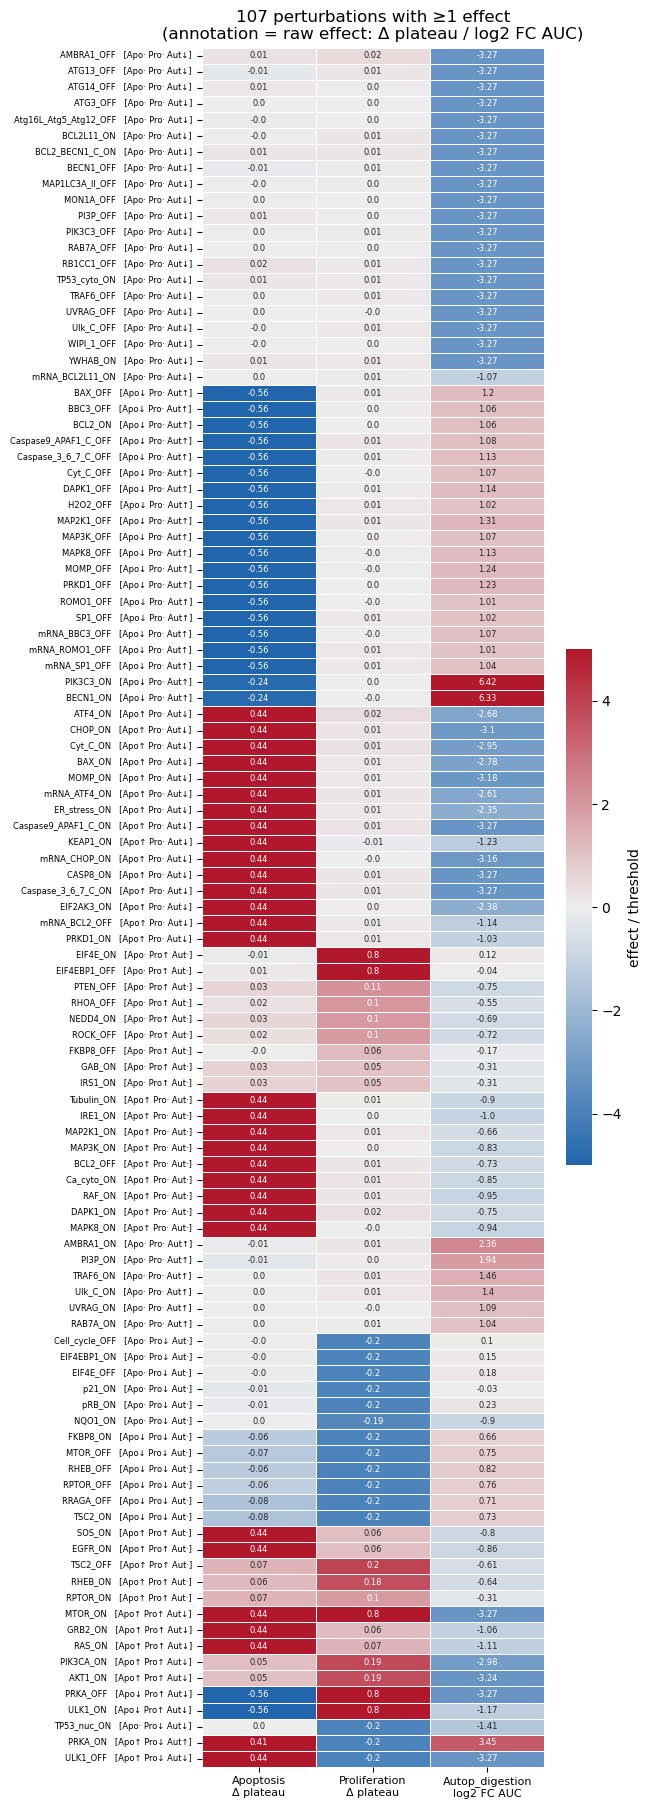

In [15]:
arrow = {'up': '↑', 'down': '↓', 'ns': '·'}
short = {'Apoptosis': 'Apo', 'Proliferation': 'Pro', 'Autop_digestion': 'Aut'}
pattern = calls.apply(lambda r: ' '.join(f'{short[n]}{arrow[r[n]]}' for n in OUTPUTS), axis=1)
annot['pattern'] = pattern

hit = annot.index[~annot['self'] & ~annot['silent'] & (calls != 'ns').any(axis=1)]
scaled = effects.loc[hit].div(pd.Series(thresholds))
order = (scaled.join(annot['pattern'])
         .assign(n=lambda d: d.groupby('pattern')['pattern'].transform('size'),
                 mag=scaled.abs().max(axis=1))
         .sort_values(['n', 'pattern', 'mag'], ascending=[False, True, False]).index)

cmap = mcolors.LinearSegmentedColormap.from_list('div', ['#2166AC', '#EEEEEE', '#B2182B'])
fig_h = max(6, 0.17 * len(order))
fig, ax = plt.subplots(figsize=(6.5, fig_h))
sns.heatmap(scaled.loc[order], cmap=cmap, center=0, vmin=-5, vmax=5,
            annot=effects.loc[order].round(2), fmt='', annot_kws={'fontsize': 6},
            cbar_kws={'label': 'effect / threshold', 'shrink': 0.3}, linewidths=0.5, linecolor='white', ax=ax)
ax.set_yticks(np.arange(len(order)) + 0.5, [f'{i}   [{annot.loc[i, "pattern"]}]' for i in order], fontsize=6)
ax.set_xticklabels(['Apoptosis\nΔ plateau', 'Proliferation\nΔ plateau', 'Autop_digestion\nlog2 FC AUC'], fontsize=8, rotation=0)
ax.set(ylabel='', title=f'{len(order)} perturbations with ≥1 effect\n(annotation = raw effect: Δ plateau / log2 FC AUC)')
fig.tight_layout()
fig.savefig(fig_dir + 'effect_heatmap.png', dpi=300, bbox_inches='tight')
fig.savefig(fig_dir + 'effect_heatmap.pdf', bbox_inches='tight')
plt.show()

In [16]:
pattern_table = (annot.loc[hit].groupby('pattern')
                 .agg(n=('node', 'size'), perturbations=('node', lambda s: ', '.join(sorted(s.index))))
                 .sort_values('n', ascending=False))
pd.set_option('display.max_colwidth', None)
pattern_table

,n,perturbations
pattern,,
Apo· Pro· Aut↓,21,"AMBRA1_OFF, ATG13_OFF, ATG14_OFF, ATG3_OFF, Atg16L_Atg5_Atg12_OFF, BCL2L11_ON, BCL2_BECN1_C_ON, BECN1_OFF, MAP1LC3A_II_OFF, MON1A_OFF, PI3P_OFF, PIK3C3_OFF, RAB7A_OFF, RB1CC1_OFF, TP53_cyto_ON, TRAF6_OFF, UVRAG_OFF, Ulk_C_OFF, WIPI_1_OFF, YWHAB_ON, mRNA_BCL2L11_ON"
Apo↓ Pro· Aut↑,20,"BAX_OFF, BBC3_OFF, BCL2_ON, BECN1_ON, Caspase9_APAF1_C_OFF, Caspase_3_6_7_C_OFF, Cyt_C_OFF, DAPK1_OFF, H2O2_OFF, MAP2K1_OFF, MAP3K_OFF, MAPK8_OFF, MOMP_OFF, PIK3C3_ON, PRKD1_OFF, ROMO1_OFF, SP1_OFF, mRNA_BBC3_OFF, mRNA_ROMO1_OFF, mRNA_SP1_OFF"
Apo↑ Pro· Aut↓,15,"ATF4_ON, BAX_ON, CASP8_ON, CHOP_ON, Caspase9_APAF1_C_ON, Caspase_3_6_7_C_ON, Cyt_C_ON, EIF2AK3_ON, ER_stress_ON, KEAP1_ON, MOMP_ON, PRKD1_ON, mRNA_ATF4_ON, mRNA_BCL2_OFF, mRNA_CHOP_ON"
Apo· Pro↑ Aut·,9,"EIF4EBP1_OFF, EIF4E_ON, FKBP8_OFF, GAB_ON, IRS1_ON, NEDD4_ON, PTEN_OFF, RHOA_OFF, ROCK_OFF"
Apo↑ Pro· Aut·,9,"BCL2_OFF, Ca_cyto_ON, DAPK1_ON, IRE1_ON, MAP2K1_ON, MAP3K_ON, MAPK8_ON, RAF_ON, Tubulin_ON"
Apo· Pro· Aut↑,6,"AMBRA1_ON, PI3P_ON, RAB7A_ON, TRAF6_ON, UVRAG_ON, Ulk_C_ON"
Apo· Pro↓ Aut·,6,"Cell_cycle_OFF, EIF4EBP1_ON, EIF4E_OFF, NQO1_ON, p21_ON, pRB_ON"
Apo↓ Pro↓ Aut·,6,"FKBP8_ON, MTOR_OFF, RHEB_OFF, RPTOR_OFF, RRAGA_OFF, TSC2_ON"
Apo↑ Pro↑ Aut·,5,"EGFR_ON, RHEB_ON, RPTOR_ON, SOS_ON, TSC2_OFF"


## Node-level view: ON vs OFF of the same node
Combining the ON and the OFF lock of the same node gives its role for each readout:
- **activator (ON↑ OFF↓)** / **inhibitor (ON↓ OFF↑)**: the readout follows the node in both directions;
- **needed (OFF only)**: the node is active in the wildtype dynamics and its loss matters, but forcing it ON adds nothing;
- **sufficient (ON only)**: the node is (mostly) inactive without inputs, so only forcing it ON has an effect.

The heatmap shows the ON and OFF effects side by side (scaled by the threshold, raw value annotated) for every
node with at least one effect.

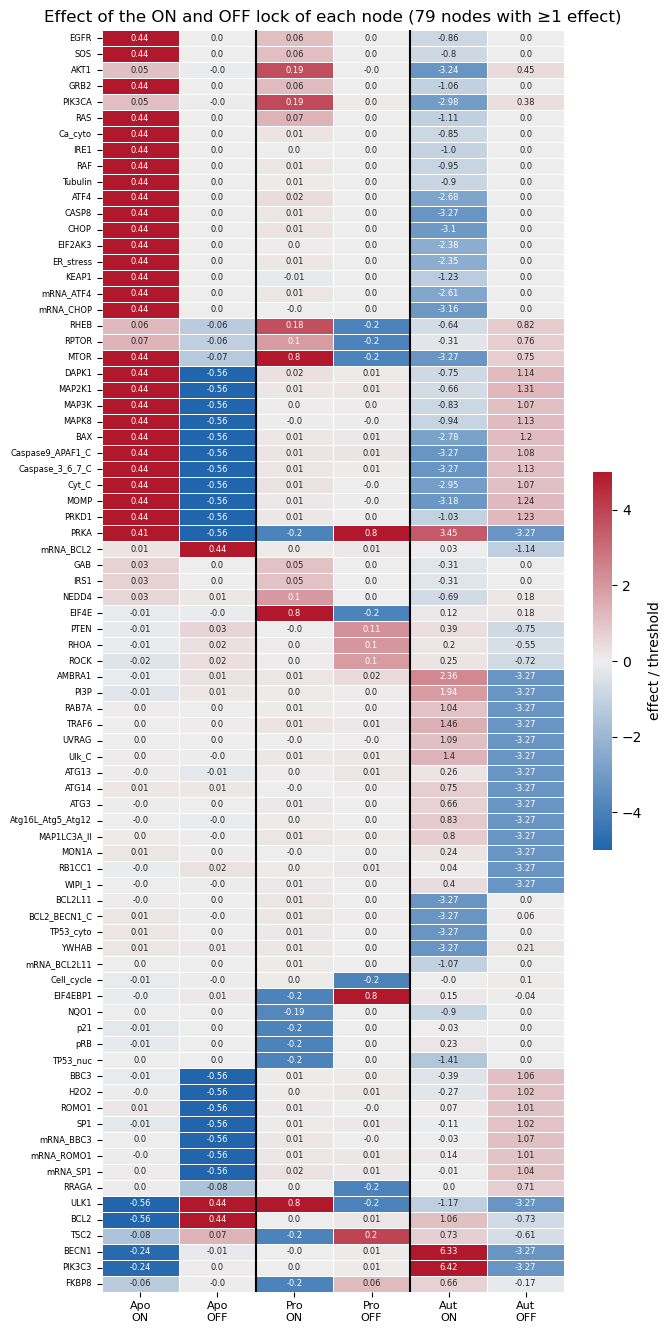

,Apoptosis,Proliferation,Autop_digestion
activator (ON↑ OFF↓),14,5,9
"activator, needed (OFF↓ only)",8,2,9
"activator, sufficient (ON↑ only)",18,9,1
inhibitor (ON↓ OFF↑),3,4,6
"inhibitor, needed (OFF↑ only)",1,3,11
"inhibitor, sufficient (ON↓ only)",3,4,19
no effect,60,80,51
same direction ON and OFF,0,0,1


In [17]:
node_effects = effects.join(annot[['node', 'mutation_type', 'self']]).query('~self')
on = node_effects[node_effects['mutation_type'] == 'ON'].set_index('node')[OUTPUTS]
off = node_effects[node_effects['mutation_type'] == 'OFF'].set_index('node')[OUTPUTS]
on, off = on.align(off, join='inner')

def node_role(s_on, s_off):
    s_on, s_off = int(np.sign(s_on)), int(np.sign(s_off))
    if s_on == 0 and s_off == 0:
        return 'no effect'
    if s_on == -s_off:
        return 'activator (ON↑ OFF↓)' if s_on > 0 else 'inhibitor (ON↓ OFF↑)'
    if s_on == 0:
        return 'activator, needed (OFF↓ only)' if s_off < 0 else 'inhibitor, needed (OFF↑ only)'
    if s_off == 0:
        return 'activator, sufficient (ON↑ only)' if s_on > 0 else 'inhibitor, sufficient (ON↓ only)'
    return 'same direction ON and OFF'

sig_on = on.apply(lambda c: np.select([c >= thresholds[c.name], c <= -thresholds[c.name]], [1, -1], 0))
sig_off = off.apply(lambda c: np.select([c >= thresholds[c.name], c <= -thresholds[c.name]], [1, -1], 0))
roles = pd.DataFrame({n: [node_role(a, b) for a, b in zip(sig_on[n], sig_off[n])] for n in OUTPUTS}, index=on.index)

# Node x (readout, lock) heatmap, rows ordered by their sign pattern
cols = pd.MultiIndex.from_product([OUTPUTS, ['ON', 'OFF']])
raw = pd.concat({(n, lock): tab[n] for n in OUTPUTS for lock, tab in [('ON', on), ('OFF', off)]}, axis=1)[cols]
sig = pd.concat({(n, lock): tab[n] for n in OUTPUTS for lock, tab in [('ON', sig_on), ('OFF', sig_off)]}, axis=1)[cols]
active = sig.index[(sig != 0).any(axis=1)]
row_order = sig.loc[active].sort_values(list(cols), ascending=False).index
scaled_nodes = raw.loc[row_order].div([thresholds[n] for n, _ in cols], axis=1)

fig, ax = plt.subplots(figsize=(7, max(6, 0.17 * len(row_order))))
sns.heatmap(scaled_nodes, cmap=cmap, center=0, vmin=-5, vmax=5, annot=raw.loc[row_order].round(2), fmt='',
            annot_kws={'fontsize': 6}, cbar_kws={'label': 'effect / threshold', 'shrink': 0.3},
            linewidths=0.5, linecolor='white', ax=ax)
for x in (2, 4):
    ax.axvline(x, color='black', lw=1.5)
ax.set_xticklabels([f'{short[n]}\n{lock}' for n, lock in cols], rotation=0, fontsize=8)
ax.set_yticks(np.arange(len(row_order)) + 0.5, row_order, fontsize=6)
ax.set(xlabel='', ylabel='', title=f'Effect of the ON and OFF lock of each node ({len(row_order)} nodes with ≥1 effect)')
fig.tight_layout()
fig.savefig(fig_dir + 'node_on_vs_off.png', dpi=300, bbox_inches='tight')
plt.show()

role_counts = roles.apply(pd.Series.value_counts).fillna(0).astype(int)
role_counts

In [18]:
# Nodes acting on each readout, grouped by role (strongest first)
for node in OUTPUTS:
    print(f'=== {node} ===')
    strength = pd.concat([on[node], off[node]], axis=1).abs().max(axis=1)
    for role, grp in roles.groupby(node):
        if role == 'no effect':
            continue
        members = strength.loc[grp.index].sort_values(ascending=False).index
        print(f'  {role} ({len(members)}): {", ".join(members)}')
    print()

=== Apoptosis ===
  activator (ON↑ OFF↓) (14): BAX, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, DAPK1, MAP2K1, MAP3K, MAPK8, MOMP, PRKA, PRKD1, MTOR, RPTOR, RHEB
  activator, needed (OFF↓ only) (8): BBC3, H2O2, ROMO1, SP1, mRNA_BBC3, mRNA_ROMO1, mRNA_SP1, RRAGA
  activator, sufficient (ON↑ only) (18): ATF4, CHOP, Tubulin, mRNA_ATF4, ER_stress, KEAP1, mRNA_CHOP, CASP8, EIF2AK3, IRE1, Ca_cyto, GRB2, RAF, RAS, SOS, EGFR, PIK3CA, AKT1
  inhibitor (ON↓ OFF↑) (3): BCL2, ULK1, TSC2
  inhibitor, needed (OFF↑ only) (1): mRNA_BCL2
  inhibitor, sufficient (ON↓ only) (3): BECN1, PIK3C3, FKBP8

=== Proliferation ===
  activator (ON↑ OFF↓) (5): MTOR, ULK1, EIF4E, RHEB, RPTOR
  activator, needed (OFF↓ only) (2): Cell_cycle, RRAGA
  activator, sufficient (ON↑ only) (9): PIK3CA, AKT1, NEDD4, RAS, GRB2, EGFR, SOS, GAB, IRS1
  inhibitor (ON↓ OFF↑) (4): PRKA, EIF4EBP1, TSC2, FKBP8
  inhibitor, needed (OFF↑ only) (3): PTEN, RHOA, ROCK
  inhibitor, sufficient (ON↓ only) (4): TP53_nuc, p21, pRB, NQO1

=== Auto

## Summary tables
Key perturbations per readout and direction (top 10 by effect size, self-locks excluded), with the
autophagy class alongside.

In [19]:
rows = []
for node in OUTPUTS:
    x = effects.loc[~annot['self'], node]
    for direction, top in [('up', x[calls.loc[x.index, node] == 'up'].nlargest(10)),
                           ('down', x[calls.loc[x.index, node] == 'down'].nsmallest(10))]:
        rows.append({'readout': node, 'direction': direction, 'n called': (calls.loc[x.index, node] == direction).sum(),
                     'top perturbations (effect)': ', '.join(f'{i} ({v:+.2f})' for i, v in top.items())})
key_table = pd.DataFrame(rows).set_index(['readout', 'direction'])
key_table

n called  \
readout         direction             
Apoptosis       up               36   
                down             28   
Proliferation   up               21   
                down             15   
Autop_digestion up               27   
                down             45   

                                                                                                                                                                                                                         top perturbations (effect)  
readout         direction                                                                                                                                                                                                                            
Apoptosis       up                                           ATF4_ON (+0.44), CHOP_ON (+0.44), MTOR_ON (+0.44), ULK1_OFF (+0.44), Cyt_C_ON (+0.44), Tubulin_ON (+0.44), BAX_ON (+0.44), MOMP_ON (+0.44), mRNA_ATF4_ON (+0.44), ER_stress_ON (+0.44)  
                down                   BAX_OFF (-0.56), BBC3_OFF (-0.56), BCL2_ON (-0.56), Caspase9_APAF1_C_OFF (-0.56), Caspase_3_6_7_C_OFF (-0.56), Cyt_C_OFF (-0.56), DAPK1_OFF (-0.56), H2O2_OFF (-0.56), MAP2K1_OFF (-0.56), MAP3K_OFF (-0.56)  
Proliferation   up                                              MTOR_ON (+0.80), PRKA_OFF (+0.80), ULK1_ON (+0.80), EIF4E_ON (+0.80), EIF4EBP1_OFF (+0.80), TSC2_OFF (+0.20), PIK3CA_ON (+0.19), AKT1_ON (+0.19), RHEB_ON (+0.18), PTEN_OFF (+0.11)  
                down                               Cell_cycle_OFF (-0.20), EIF4EBP1_ON (-0.20), EIF4E_OFF (-0.20), FKBP8_ON (-0.20), MTOR_OFF (-0.20), PRKA_ON (-0.20), RHEB_OFF (-0.20), RPTOR_OFF (-0.20), RRAGA_OFF (-0.20), TP53_nuc_ON (-0.20)  
Autop_digestion up                                            PIK3C3_ON (+6.42), BECN1_ON (+6.33), PRKA_ON (+3.45), AMBRA1_ON (+2.36), PI3P_ON (+1.94), TRAF6_ON (+1.46), Ulk_C_ON (+1.40), MAP2K1_OFF (+1.31), MOMP_OFF (+1.24), PRKD1_OFF (+1.23)  
                down       AMBRA1_OFF (-3.27), ATG13_OFF (-3.27), ATG14_OFF (-3.27), ATG3_OFF (-3.27), Atg16L_Atg5_Atg12_OFF (-3.27), BCL2L11_ON (-3.27), BCL2_BECN1_C_ON (-3.27), BECN1_OFF (-3.27), CASP8_ON (-3.27), Caspase9_APAF1_C_ON (-3.27)

In [20]:
# One row per simulation (wildtype first: its metrics are the reference, effects are empty)
summary = (metrics.join(effects.add_suffix('_effect')).join(effects_extra).join(calls.add_suffix('_call')))
summary = annot.reindex(summary.index).join(summary)
summary = pd.concat([summary.loc[['wildtype']], summary.drop(index='wildtype')])
summary.to_csv(results_dir + 'maboss_perturbation_noinput_output_effects.csv')
roles.to_csv(results_dir + 'maboss_perturbation_noinput_node_roles.csv')
print('saved:', results_dir + 'maboss_perturbation_noinput_output_effects.csv')
print('saved:', results_dir + 'maboss_perturbation_noinput_node_roles.csv')
summary.drop(index='wildtype').sort_values('Apoptosis_effect').head()

saved: ../../../../results/maboss_perturbation_noinput_output_effects.csv
saved: ../../../../results/maboss_perturbation_noinput_node_roles.csv


,node,mutation_type,self,silent,autophagy_class,autophagy_amplitude,pattern,Apoptosis_late,Apoptosis_auc,Apoptosis_t_half,...,Autop_digestion_persistence,Apoptosis_effect,Proliferation_effect,Autop_digestion_effect,Apoptosis_auc_delta,Apoptosis_t_half_delta,Autop_digestion_peak_lfc,Apoptosis_call,Proliferation_call,Autop_digestion_call
mutation,,,,,,,,,,,,,,,,,,,,,
Caspase_3_6_7_C_OFF,Caspase_3_6_7_C,OFF,False,False,sustained,ns,Apo↓ Pro· Aut↑,0.0,0.000000,NaN,...,0.946663,-0.562794,0.005358,1.128329,-14.665469,NaN,0.836396,down,ns,up
MAP3K_OFF,MAP3K,OFF,False,False,sustained,ns,Apo↓ Pro· Aut↑,0.0,0.033221,NaN,...,0.889672,-0.562794,0.003773,1.065131,-14.632248,NaN,0.850783,down,ns,up
MAPK8_OFF,MAPK8,OFF,False,False,sustained,ns,Apo↓ Pro· Aut↑,0.0,0.039251,NaN,...,0.914226,-0.562794,-0.002097,1.132936,-14.626218,NaN,0.828449,down,ns,up
MOMP_OFF,MOMP,OFF,False,False,sustained,ns,Apo↓ Pro· Aut↑,0.0,0.000000,NaN,...,0.952549,-0.562794,-0.003600,1.242838,-14.665469,NaN,0.961714,down,ns,up
H2O2_OFF,H2O2,OFF,False,False,sustained,ns,Apo↓ Pro· Aut↑,0.0,0.000000,NaN,...,0.884472,-0.562794,0.008821,1.020380,-14.665469,NaN,0.824323,down,ns,up


## Key findings
*(numbers refer to the saved simulation file; re-check them if the perturbation screen is re-simulated)*

**Apoptosis behaves as a switch.** Most effects saturate: the plateau goes to 1 (+0.44) or to 0 (−0.56).
- *Increase* (36 perturbations): gain of the intrinsic/caspase cascade (`BAX`, `MOMP`, `Cyt_C`, `Caspase9_APAF1_C`,
  `Caspase_3_6_7_C`, `CASP8`), of the ER-stress/UPR arm (`ER_stress`, `EIF2AK3`, `ATF4`, `CHOP`), of the stress-kinase
  arm (`RAF`, `MAP2K1`, `MAP3K`, `MAPK8`, `DAPK1`, `PRKD1`, `Ca_cyto`) and of the growth-factor arm (`EGFR`, `SOS`, `GRB2`,
  `RAS`), plus `MTOR_ON` and `ULK1_OFF`. The upstream caspase locks also make apoptosis much *faster* (t½ 1–5 vs 14);
  `BID_ON`, `BBC3_ON` and `BCL2L11_ON` advance it by 9 ticks without changing the plateau.
- *Decrease* (28): 18 OFF locks on the pro-apoptotic chain and its inputs (`BAX`, `BBC3`, `MOMP`, `Cyt_C`, caspases,
  `MAPK8`, `MAP3K`, `MAP2K1`, `DAPK1`, `PRKD1`, `H2O2`/`ROMO1`, `SP1`) plus `BCL2_ON` abolish apoptosis; `PRKA_OFF` and
  `ULK1_ON` abolish it too. Constitutive autophagy (`BECN1_ON`, `PIK3C3_ON`, −0.24) and loss of mTORC1
  (`MTOR`/`RHEB`/`RPTOR`/`RRAGA` OFF, `TSC2`/`FKBP8` ON, −0.06 to −0.08) give partial protection.

**Proliferation is set by the mTORC1 → EIF4E axis and the cell-cycle brakes.**
- Full proliferation (+0.80): `MTOR_ON`, `EIF4E_ON`, `EIF4EBP1_OFF`, `PRKA_OFF`, `ULK1_ON`; partial (+0.1–0.2):
  `TSC2_OFF`, `PIK3CA_ON`, `AKT1_ON`, `RHEB_ON`, `PTEN_OFF`, `RHOA_OFF`, `ROCK_OFF`, `NEDD4_ON`.
- Loss of proliferation (→ 0): mTORC1 loss (`MTOR`, `RHEB`, `RPTOR`, `RRAGA` OFF, `TSC2`/`FKBP8` ON), `EIF4E_OFF`/`EIF4EBP1_ON`,
  cell-cycle brakes (`p21`, `pRB`, `TP53_nuc`, `NQO1` ON, `Cell_cycle_OFF`), `PRKA_ON` and `ULK1_OFF`.

**Autop_digestion: the shape of the transient matters more than its level.**
- *Abolished* (37): loss of the core machinery (ULK complex, `AMBRA1`, `BECN1`, `PIK3C3`/`PI3P`/`UVRAG`/`ATG14`, `WIPI_1`,
  `ATG3`, `Atg16L_Atg5_Atg12`, `MAP1LC3A_II`, `RAB7A`/`MON1A`), gain of its inhibitors (`MTOR`, `AKT1`, `PIK3CA`,
  `BCL2L11`, `BCL2_BECN1_C`, `YWHAB`, `TP53_cyto`) and the locks that trigger apoptosis early (caspases, `MOMP`, `BAX`, `Cyt_C`,
  `ER_stress`/`ATF4`/`CHOP`).
- *Terminated* (18): the transient starts but then switches fully off. 17/18 of these locks drive apoptosis to ≈1 with
  a wildtype-like onset (t½ 13–15), so autophagy starts before the caspases switch on, then every trajectory dies and
  digestion stops (the 18th is `ULK1_ON`).
- *Sustained* (20): every lock that abolishes apoptosis through the intrinsic chain turns the transient into a low,
  non-decaying plateau (≈0.03, about 3× the wildtype late level), and `BECN1_ON` / `PIK3C3_ON` lock autophagy fully ON.
- *Amplified transient*: `AMBRA1_ON`, `PI3P_ON`, `TRAF6_ON`, `Ulk_C_ON` (peak 2–5×) and `PRKA_ON` (≈18×, but then terminated).
- So the wildtype transient is a consequence of the apoptotic switch: `Caspase_3_6_7_C` inhibits `BECN1` and `AMBRA1`, so
  trajectories that commit to apoptosis lose their autophagy. Apoptosis and autophagy are anti-correlated across the screen
  (`Apo↓ Aut↑`: 20 perturbations; `Apo↑ Aut↓`: 15, plus 5 more that also raise proliferation — `AKT1`, `GRB2`, `MTOR`,
  `PIK3CA`, `RAS` ON).

**The AMPK–ULK1 axis is the only one that moves all three readouts.** `PRKA_ON` gives apoptosis ↑, proliferation ↓ and a
large but terminated autophagy burst. `PRKA_OFF` and `ULK1_ON` give the opposite (no apoptosis, full proliferation), and
`ULK1_OFF` mirrors `PRKA_ON`. That locking `ULK1` ON abolishes apoptosis and drives full proliferation (`ULK1 = !MTOR & PRKA`)
is counter-intuitive and worth tracing through the network before interpreting it biologically.